# P03

## Todo - `create_agent()` 로 agent 3개 만들기
우선 각자 다른 3개의 Agent 를 만들고 테스트 해 보도록 합니다.

```py
user_prompt = '새로운 스마트 안경을 만들고 싶어.'
```
### 1. 자료조사 Agent
#### 사용 Tool
- Tavily Search (검색)
- 추가로 원하는 Tool 붙이기 가능
#### 예시코드
```py
research_agent = create_agent(
    ...
    tools=[tavily_tool, ]
)
research_result = research_agent.invoke(user_prompt)['messages'][-1]
```

### 2. 디자이너 Agent
#### 사용 Tool
- Tavily Search (검색)
- 추가로 원하는 Tool 붙이기 가능
#### 예시코드
```py
design_agent = create_agent(
    ...
    tools=[tavily_tool, ]
)
design_result = design_agent.invoke(user_prompt)['messages'][-1]
```

### 3. PM Agent
#### 사용 Tool
- 없음
- 모델을 gpt-5로 사용해보기
#### 예시코드
```py
pm_agent = create_agent(
    ...
)
report = pm_agent.invoke(
    f'''요청 주문: {user_prompt}
    ---
    자료조사 : {research_result}
    ---
    디자인 결정 : {design_result}
    '''
)['messages'][-1]

print(report)
```

In [1]:
from langchain.agents import create_agent
from langchain.messages import HumanMessage, SystemMessage
from dotenv import load_dotenv

load_dotenv()

user_prompt = '스마트 안경 조사 부탁.'


In [6]:
# uv add langchain-tavily
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(
    # .env 에 TAVILY_API_KEY 가 있으면 알아서 인증
    max_results=5,
    topic='general'
)


In [7]:
# 자료조사 Agent
RESEARCH_SYS_PROMPT = '''당신은 10년 차 시니어 시장 분석가입니다.
사용자가 제시한 [프로젝트 주제]에 대해 다음 세 가지를 반드시 포함하여 리포트를 작성하세요.

현재 시장 트렌드 및 수요 분석

예상 타겟 고객층 (연령, 직업, 특징)

잠재적 경쟁사 또는 유사 서비스의 장단점
사실에 기반한 논조로, 불필요한 서론 없이 핵심만 요약해 주세요.'''

research_agent = create_agent(
    model='openai:gpt-4.1-mini',
    tools=[tavily_tool, ],
    system_prompt=RESEARCH_SYS_PROMPT,
)
research_result = research_agent.invoke({
    'messages': [
        HumanMessage(user_prompt)
    ]
})['messages'][-1]


In [8]:
research_result.pretty_print()

================================== Ai Message ==================================

스마트 안경 시장 분석 리포트

1. 현재 시장 트렌드 및 수요 분석
- 2024년 스마트 안경 시장은 AI, 증강현실(AR), 혼합현실(MR), 가상현실(VR) 기술이 통합된 스마트 안경 부문이 주도하고 있으며, 실질적인 연평균 성장률(CAGR)이 높다.
- 스마트 안경은 손 없는 네비게이션, 실시간 정보 제공, 시각적 경험 강화에 초점을 맞추고 있다.
- 글로벌 시장 규모는 2024년 약 193억 달러에서 2030년까지 최대 826억 달러로 예상되며, 2023년 대비 출하량이 210% 이상 증가하는 등 폭발적 성장 중이다.
- 시장 확대는 메타(Meta)의 레이벤 메타(Ray-Ban Meta) 스마트 안경 성공이 견인하고 있으며, 중국을 중심으로 다수의 신규 AI 스마트 안경 출시가 활성화되고 있다.
- 다만, 높은 생산비용, 배터리 수명 제한, 개인정보 보호 문제, 규제 등의 장애 요소도 존재한다.

2. 예상 타겟 고객층
- 연령대: 20대 후반부터 50대까지, 특히 기술 친화적이며 최신 IT 기기 활용에 적극적인 층.
- 직업군: IT 및 테크 산업 종사자, 디자인·엔터테인먼트·교육 관련 전문가, 운동 및 피트니스 애호가, 의료 및 산업 현장 근로자 등 스마트 기능을 적극 활용할 필요가 있는 전문직 및 일반 소비자.
- 특징: 실시간 정보 접근, 핸즈프리 작업, AR 기능 활용에 관심 있는 사용자로 스마트폰과 연동해 생산성 및 엔터테인먼트 경험 향상을 원하는 층.

3. 잠재적 경쟁사 또는 유사 서비스의 장단점
- 주요 경쟁사: 메타(Meta, Ray-Ban Meta), Xreal, 레이네오(Rayneo), Rokid, 샤오미 등
- 장점:
  * 메타는 AI와 대규모 언어 모델 라마(LIama)를 활용해 고도화된 사용자 경험 제공.
  * 다양한 중국 기업은 공격적인 신제품 출시로 신흥 시장 선점 중.
 

In [9]:
# 디자이너 Agent
DESIGN_SYS_PROMPT = '''당신은 트렌드를 선도하는 Product 크리에이티브 디렉터입니다.
사용자가 제시한 프로덕트를 바탕으로 Product 컨셉을 기획하세요.
다음 항목을 반드시 포함해야 합니다.

핵심 디자인 키워드 3가지 (예: 미니멀, 레트로, 신뢰감 등)
핵심 유저 인터페이스(UI) 포인트 2가지

개발자와 기획자가 바로 상상할 수 있도록 구체적이고 감각적으로 묘사하세요.'''

design_agent = create_agent(
    model='openai:gpt-4.1-mini',
    tools=[tavily_tool, ],
    system_prompt=DESIGN_SYS_PROMPT,
)
design_result = design_agent.invoke({
    'messages': [
        HumanMessage(user_prompt)
    ]
})['messages'][-1]

In [10]:
design_result.pretty_print()

================================== Ai Message ==================================

2024년 스마트 안경 시장은 AI 통합과 사용자 편의성 극대화가 핵심 트렌드로 부상하고 있습니다. 주요 내용을 바탕으로 스마트 안경의 컨셉 기획안을 제안드립니다.

핵심 디자인 키워드:
1. 스마트 최적화 - 경량화 및 일상 착용 가능하도록 편안한 착용감과 세련된 미니멀 디자인 강조
2. 실용성과 혁신 - AI 기반 음성 지원 및 실시간 데이터 표시 기능으로 업무와 일상 모두에 자연스럽게 융합
3. 정밀 기술감 - 세련된 메탈 또는 하이테크 소재 사용 및 디스플레이 기술 내장으로 미래지향적 이미지 구현

핵심 유저 인터페이스(UI) 포인트:
1. 음성 인식 중심 조작 - 시각·터치 제어를 최소화하고 광범위한 음성 명령으로 모든 기능을 손쉽게 실행할 수 있도록 디자인
2. 실시간 투명 디스플레이 - 사용자가 주변 환경을 자연스럽게 인식하면서도 필요한 정보를 시선 내에 즉시 확인 가능한 AR형 UI 적용

구체적 묘사:
- 프레임은 초경량 티타늄과 탄소 섬유 탄성과 착용감을 극대화하며, 무게는 일반 안경수준으로 유지.
- 렌즈는 반투명 OLED 미니 디스플레이 내장, 일상 시야를 해치지 않는 선명한 정보 표시가 가능.
- 마이크, 스피커, 센서가 프레임 내장돼 자연스러운 대화형 AI 경험 제공.
- UI는 음성 명령으로 착용자가 날씨, 일정, 메시지 알림, 번역 등의 정보를 즉시 호출 및 제어.
- 사용자 눈동자 움직임 추적 기술로 자연스런 화면 전환 및 포커스 조절로 눈의 부담 최소화.

요약: 2024년 스마트 안경은 사용자 편의와 AI 기술 조합에 집중, 세련된 디자인과 직관적 음성 UI가 핵심입니다. 업무 효율과 일상생활에 매끄럽게 녹아드는 혁신적 웨어러블 기기로 자리매김하는 컨셉을 추천합니다.


In [11]:
# PM Agent
PM_SYS_PROMPT = '''당신은 프로젝트를 총괄하는 헤드 PM(Product Manager)입니다.
아래 제공된 자료조사 리포트와 디자인 방향성을 종합하여 최종 '원페이지 기획서(1-Page PRD)'를 작성하세요.

기획서는 다음 구조를 따르세요:

서비스 한 줄 소개

타겟 고객 및 해결하려는 문제 (자료조사 바탕)

핵심 기능 및 시각적 컨셉 (디자인 방향성 바탕)

다음 액션 플랜 (PM의 관점에서 제안)

'''

PM_USER_PROMPT = f'''요청 주문: {user_prompt}
    ---
    자료조사 : {research_result.content}
    ---
    디자인 : {design_result.content}
'''

pm_agent = create_agent(
    model='openai:gpt-5-mini',
    system_prompt=PM_SYS_PROMPT,
)
report = pm_agent.invoke({
    'messages': [
        HumanMessage(PM_USER_PROMPT)
    ]
})['messages'][-1]

report.pretty_print()

================================== Ai Message ==================================

서비스 한 줄 소개
- 일상·업무에 자연스럽게 녹아드는 경량 AI·AR 스마트글래스: 음성주도 실시간 정보·네비게이션·번역을 제공하고, 눈에 거슬리지 않는 투명 AR 디스플레이로 ‘손 없는’ 생산성 경험을 구현.

타겟 고객 및 해결하려는 문제 (자료조사 바탕)
- 주요 타깃
  - 20대 후반~50대 기술 친화적 사용자(프로슈머), IT·디자인·교육·의료·산업 현장 종사자, 운동·피트니스 애호가
- 사용자가 겪는 문제(해결 포인트)
  - 핸즈프리 정보 접근 필요: 작업 중 스마트폰 조작의 불편·비효율
  - 실시간 맥락 정보 부족: 네비/작업 지시/번역/알림을 즉시 확인하기 어려움
  - 착용 지속성 문제: 기존 기기들은 무겁고 일상 착용에 부적합
  - 개인정보·보안 우려: 주변 녹화·데이터 송수신에 대한 불신
  - 배터리·비용 제약: 긴 사용시간과 합리적 가격 필요

핵심 기능 및 시각적 컨셉 (디자인 방향성 바탕)
- 핵심 기능(우선순위: MVP → 확장)
  1. 음성 중심 인터랙션(오프라인 키워드 인식 + LLM 연동) — 알림, 일정, 번역, 질의응답
  2. 투명 AR 미니 디스플레이(반투명 OLED) — 시선 내에 정보 카드형으로 제공(글자·아이콘 최소화)
  3. 초경량 프레임(티타늄+탄소섬유), 안경 수준 무게/착용감 — 장시간 착용 목표
  4. 필수 센서군: 마이크 어레이, 소형 스피커/바이브, 눈동자 추적(시선 기반 포커스), IMU(제스처/포즈 인식)
  5. 배터리·전력관리: 스냅샷형 AR(짧게 표시)으로 전력 효율화 + 외부 보조 배터리 옵션
  6. 개인정보·보안 기능: 카메라/녹음 하드웨어 스위치, 기본 온디바이스 처리, 암호화된 클라우드 옵션
  7. 플랫폼 연동 API: 스마트폰(안드로이드/iOS) 연동, 타사 앱(네비·피트니스·의료) SDK
- UX 원칙
  - 음성 우선,

## Agent를 Graph로 조립하기
- Node로 감싸라

In [ ]:
from langgraph.graph import MessagesState, StateGraph, START, END

class TeamState(MessagesState):
    # messages 는 셋업
    research: str
    design: str


def research_node(state: TeamState):
    result = research_agent.invoke({
        'messages': state['messages']  # [HumanMessage()]
    })
    return {
        # TeamState 중에서, 'research'를 에이전트의 조사 결과 str만 뽑아서 갱신
        'research': result['messages'][-1].content
    }


def design_node(state: TeamState):
    result = design_agent.invoke({
            'messages': state['messages']
    })
    return {
        # TeamState 중에서, 'design'만 에이전트의 조사 결과 str만 뽑아서 갱신
        'design': result['messages'][-1].content
    }


def pm_node(state: TeamState):
    PM_USER_PROMPT = f'''요청 주문: {state['messages'][-1].content}
    ---
    자료조사 : {state['research']}
    ---
    디자인 : {state['design']}
'''
    result = pm_agent.invoke({
        'messages': [HumanMessage(PM_USER_PROMPT)]
    })
    final_ai_msg = result['messages'][-1]  # AI
    return {'messages': [final_ai_msg]}

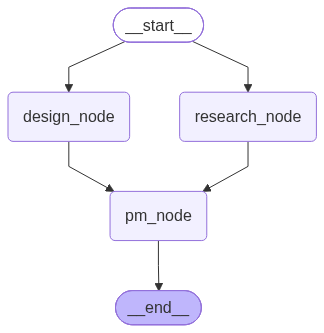

In [19]:
builder = StateGraph(TeamState)
builder.add_node(research_node)
builder.add_node(design_node)
builder.add_node(pm_node)
builder.add_edge(START, 'research_node')
builder.add_edge(START, 'design_node')
builder.add_edge('research_node', 'pm_node')
builder.add_edge('design_node', 'pm_node')
builder.add_edge('pm_node', END)
graph = builder.compile()
graph


In [21]:
res = graph.invoke({
    'messages': [
        HumanMessage('스마트 안경 기획하자')
    ]
})

In [22]:
for msg in res['messages']:
    msg.pretty_print()

================================ Human Message =================================

스마트 안경 기획하자
================================== Ai Message ==================================

서비스 한 줄 소개
- AI 기반 경량 스마트 안경: 일상에서 자연스럽게 정보를 접하고 제스처·음성으로 제어하는 ‘패션형 AR 글래스’ — 실시간 번역·네비·헬스·알림을 개인 프라이버시 우선 방식으로 제공.

타겟 고객 및 해결하려는 문제 (자료조사 바탕)
- 주요 타겟
  - 20–40대 밀레니얼·Z: 패션성과 실시간 정보(네비, 번역, 알림)를 원함 — 얼리어답터 성향.
  - 산업/전문직(30–50대): 핸즈프리 정보·원격지원 필요(유지보수·의료·물류).
  - 피트니스·건강 사용자: 실시간 바이탈·AI 코칭 수요.
  - 고령자·장애인(보조기기): 원격의료·보조 기능 가능성(지원 필요).

- 해결해야 할 핵심 문제
  - 배터리·발열: 장시간 사용의 가장 큰 제약.
  - 개인정보·신뢰성: 카메라·음성 기반의 사회적 우려와 규제 리스크.
  - 사회적 수용성·디자인: 어색한 외관은 채택 장벽.
  - 가격 경쟁력 및 사용 복잡성: 초기 고가·설정 난이도는 확산 저해.
  - 콘텐츠·생태계: 유용한 AR 경험(앱·서비스) 부족.

핵심 기능 및 시각적 컨셉 (디자인 방향성 바탕)
- 핵심 기능(우선순위: MVP → 확장)
  1. 필수(MVP)
     - AR HUD 기본: 투명 정보 오버레이(알림, 네비, 일정).
     - 스마트 터치 다리 + 간단 제스처(탭/스와이프) 및 음성비서 연동.
     - 실시간 AI 번역(음성·텍스트)·간편 네비 가이드.
     - 블루투스·Wi‑Fi 연결, 스마트폰 연동 앱(설정·컨텐츠).
     - 경량화 하드웨어: 목표 무게 <50g, 착용 지속시간(일상 사용) 6+시간 활성(저전력 모드로 18–